              precision    recall  f1-score   support

          No       0.84      0.99      0.91       247
         Yes       0.50      0.04      0.08        47

    accuracy                           0.84       294
   macro avg       0.67      0.52      0.50       294
weighted avg       0.79      0.84      0.78       294



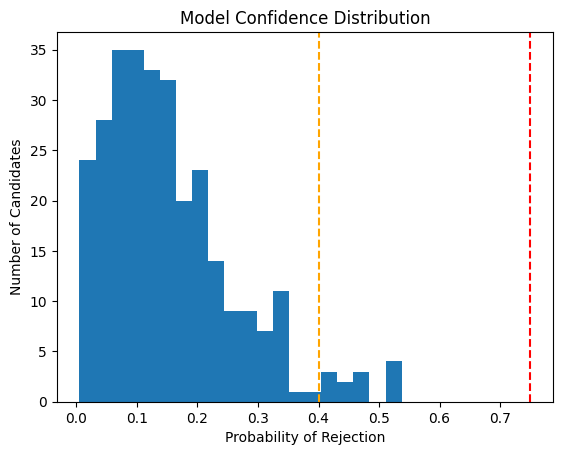

,prob_reject
0.80,0.225822
0.90,0.312451
0.95,0.343628


In [ ]:
# Note on data usage
# This dataset is synthetic and anonymized.
# For this project, only features plausibly available at early screening were used.

import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

df.shape
df.columns
df.describe()


# Feature selection rationale
# To simulate an early-stage hiring screen, only variables plausibly available at the time of application were included.
# Post-hire metrics (e.g., performance ratings, satisfaction scores) were excluded to avoid data leakage and unrealistic modeling assumptions.

# Bias considerations
# Several variables (e.g., education field, job role) may act as proxies for demographic or socioeconomic factors.
# This project evaluates model behavior with this risk in mind rather than assuming neutrality.

selected_features = [
    "Age",
    "Education",
    "EducationField",
    "JobRole",
    "TotalWorkingYears",
    "YearsSinceLastPromotion",
    "NumCompaniesWorked"
]

# Converting categories to numbers

X = df[selected_features]
y = df["Attrition"]

X = pd.get_dummies(X, drop_first=True)

X.shape
X.head()

# Training
# Evaluating how the model performs on unseen candidates
# rather than memorizing the training data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Testing
# Logistic Regression – a transparent baseline model – was chosen on purpose
# Interpretable, used in most hiring models

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

# Initial model performance
# The baseline logistic regression model achieves moderate performance but exhibits asymmetric errors.
# False negatives are particularly concerning in a hiring context, as they may exclude qualified candidates early in the pipeline.
# This motivates exploring confidence-based thresholds and human-in-the-loop review.

y_test.value_counts(normalize=True)

pd.Series(y_pred).value_counts(normalize=True)

# Turning probabilities into trust levels

y_prob = model.predict_proba(X_test)[:, 1]

results = X_test.copy()
results["true_label"] = y_test.values
results["predicted_label"] = y_pred
results["prob_reject"] = y_prob
results.head()

# High-confidence reject: AI can act alone
# Borderline: human review
# Low-confidence reject/advance: human decision

high_conf_reject = results["prob_reject"] > 0.75
borderline = (results["prob_reject"] >= 0.40) & (results["prob_reject"] <= 0.75)
low_conf = results["prob_reject"] < 0.40

# Case 1: autonomous AI decision

from sklearn.metrics import confusion_matrix

confusion_matrix(
    results["true_label"],
    results["predicted_label"]
)

# Case 2: hybrid
# AI rejects only high confidence cases
# The rest is decided upon human review

hybrid_decision = results["predicted_label"].copy()
hybrid_decision[~high_conf_reject] = "Human Review"

# Tradeoff: risk reduction, efficiency increase

results["decision"] = "Human Review"
results.loc[high_conf_reject, "decision"] = "Auto Reject"

results["decision"].value_counts()

# False negatives (good candidates rejected): if most are borderline – support for human review

false_negatives = results[
    (results["true_label"] == "No") &
    (results["predicted_label"] == "Yes")
]

false_negatives.shape

# Trust and autonomy analysis
# The model performs reliably in high-confidence cases, suggesting that AI can safely automate low-risk rejections.
# However, a significant portion of errors occur in borderline cases, where model confidence is lower.
# An AI+human approach preserves efficiency while reducing the risk of excluding qualified candidates.

import matplotlib.pyplot as plt

plt.hist(results["prob_reject"], bins=20)
plt.axvline(0.75, color="red", linestyle="--")
plt.axvline(0.40, color="orange", linestyle="--")
plt.xlabel("Probability of Rejection")
plt.ylabel("Number of Candidates")
plt.title("Model Confidence Distribution")
plt.show()

# Although the model achieves reasonable overall accuracy, it rarely produces high-confidence rejection decisions.
# This suggests that fully autonomous rejection would apply to very few candidates and that most decisions fall into a borderline region requiring human review.

results["prob_reject"].quantile([0.8, 0.9, 0.95])

# High-confidence cases were defined relative to the model’s own uncertainty distribution.
# Confidence and trust analysis
# The model assigns low rejection probabilities to most candidates, with very few predictions exceeding high-confidence thresholds.
# This indicates that while the model may be useful as a decision-support tool, it is not well-suited for fully autonomous rejection decisions.
# Most cases fall into a borderline confidence region where human judgment remains necessary.
